# Оптимизация функционала банковского приложения: повышение удобства использования.

> Банк «Деньги для Вас» столкнулся с низкой активностью клиентов в своем мобильном приложении. Для увеличения вовлеченности и лояльности команда продукта разработала и внедрила новый, улучшенный интерфейс (вариант B) с упрощенной навигацией, быстрыми переводами по шаблонам и персональными финансовыми советами.

> Был проведен А/Б-тест:
>
> •	Группа A (Контрольная): Пользователи продолжали использовать приложение со старым интерфейсом.
>
> •	Группа B (Тестовая): Пользователям был предоставлен доступ к новому интерфейсу.

>Эксперимент длился 2 недели. Вам, как аналитику, поручено проанализировать результаты эксперимента, оценить его успешность и построить модель для прогнозирования ежедневной посещаемости приложения, чтобы помочь банку в планировании ресурсов.


## 1. Постановка задачи

1.	Оценить успешность А/Б-теста: Определить, привел ли новый интерфейс (Группа B) к статистически значимому улучшению ключевых метрик по сравнению со старым интерфейсом (Группа A).

2.	Построить прогнозную модель: Разработать регрессионную модель для прогнозирования ежедневной посещаемости приложения на основе исторических данных.

3.	Визуализировать результаты: Создать интерактивный дашборд для мониторинга основных метрик и результатов исследования.

4.	Подготовить презентацию: Сформулировать выводы и рекомендации для руководства банка в виде лаконичной презентации.

## 2. Импорты библиотек и создание функций

**Библиотеки**

In [495]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu
from scipy.stats import shapiro
from scipy.stats import chi2_contingency
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

**Функции**

In [506]:
# первая функция

def regression_stat(model, name):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    rmse = root_mean_squared_error(y_test, y_pred)

    print(f"\n=== {name} ===")
    print(f"MAE: {mae:.2f} посещений")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSE: {rmse:.2f}")
    print(f"Модель ошибается в среднем на {mae:.2f} посещений, что составляет {mape:.2f}% от среднего значения")

    return y_pred

> Первая функция обучает модель регрессии, строит прогноз и рассчитывает основные метрики качества (MAE, MAPE, RMSE), позволяя сравнивать эффективность различных моделей.

In [507]:
# вторая функция

def plot_metric(data, metric, title, ylabel):
    plt.figure(figsize=(6,5))
    
    sns.barplot(data=data, x='group', y=metric, hue='group', legend=False)
    
    # подписи значений
    for i, row in data.iterrows():
        value = row[metric]
        plt.text(i, value * 1.01, f"{value:.2f}", ha='center')
    
    plt.title(title)
    plt.xlabel('Группа')
    plt.ylabel(ylabel)

> Вторая функция plot_metric используется для визуализации средних значений метрик по группам A и B в виде столбчатой диаграммы.

## 3. Загрузка данных


- users_ab.csv - информация о пользователях, участвовавших в эксперименте.
- events_ab.csv - логи событий в приложении за период эксперимента.
- visits_daily.csv - ежедневная агрегированная статистика по посещаемости приложения за последние 6 месяцев (для прогнозной модели).

In [616]:
users = pd.read_csv('users_ab.csv')
events = pd.read_csv('events_ab.csv')
visits = pd.read_csv('visits_daily.csv')

## 4. Исследование данных на качество и предобработка

### 4.0 Смотрим на данные

In [509]:
events.info()
events.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 334308 entries, 0 to 334307
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           334308 non-null  str    
 1   event_dt          334308 non-null  str    
 2   event_type        334308 non-null  str    
 3   screen_name       129535 non-null  str    
 4   button_name       77495 non-null   str    
 5   amount            51855 non-null   float64
 6   transaction_type  51909 non-null   str    
dtypes: float64(1), str(6)
memory usage: 17.9 MB


,user_id,event_dt,event_type,screen_name,button_name,amount,transaction_type
0,user_00000,2025-11-07 18:08:06.488811,login,NaN,NaN,NaN,NaN
1,user_00000,2025-11-07 18:08:53.488811,screen_view,transfers,NaN,NaN,NaN
2,user_00000,2025-11-07 18:09:38.488811,button_click,NaN,transfer,NaN,NaN
3,user_00000,2025-11-07 18:10:13.488811,screen_view,main,NaN,NaN,NaN
4,user_00000,2025-11-07 18:10:32.488811,button_click,NaN,payment,NaN,NaN
5,user_00000,2025-11-07 18:11:21.488811,screen_view,payments,NaN,NaN,NaN
6,user_00000,2025-11-07 18:12:05.488811,button_click,NaN,support,NaN,NaN
7,user_00000,2025-11-07 18:12:38.488811,transaction,NaN,NaN,25143.43,transfer
8,user_00000,2025-11-07 18:13:17.380951,logout,NaN,NaN,NaN,NaN
9,user_00000,2025-11-02 06:41:06.488811,login,NaN,NaN,NaN,NaN


In [510]:
users.info()
users.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   5025 non-null   str    
 1   group     5025 non-null   str    
 2   age       4875 non-null   float64
 3   city      4773 non-null   str    
 4   device    5017 non-null   str    
 5   reg_date  5025 non-null   str    
dtypes: float64(1), str(5)
memory usage: 235.7 KB


,user_id,group,age,city,device,reg_date
0,user_00000,A,39.0,Другой,Android,2022-11-28
1,user_00001,B,33.0,Москва,iOS,2025-02-02
2,user_00002,A,41.0,Новосибирск,iOS,2023-05-11
3,user_00003,B,50.0,Санкт-Петербург,Android,2024-08-03
4,user_00004,A,32.0,NaN,Android,2024-01-22
5,user_00005,B,32.0,Екатеринбург,iOS,2024-10-22
6,user_00006,A,50.0,Екатеринбург,iOS,2024-01-25
7,user_00007,B,42.0,Екатеринбург,Android,2025-03-12
8,user_00008,A,30.0,Санкт-Петербург,Android,2025-10-02
9,user_00009,B,40.0,NaN,iOS,2023-09-05


In [511]:
visits.info()
visits.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Дата события  181 non-null    str  
 1   visits        181 non-null    int64
 2   holiday_flag  181 non-null    int64
dtypes: int64(2), str(1)
memory usage: 4.4 KB


,Дата события,visits,holiday_flag
0,2025-05-21,11461,1
1,2025-05-22,9503,0
2,2025-05-23,14367,0
3,2025-05-24,9185,1
4,2025-05-25,9098,1
5,2025-05-26,9645,0
6,2025-05-27,9272,0
7,2025-05-28,11381,0
8,2025-05-29,10750,0
9,2025-05-30,13149,0


### 4.1 Приведение данных к стандарту

In [512]:
# Привести названия столбцов к snake_case
users.columns = users.columns.str.lower().str.replace(' ', '_')
events.columns = events.columns.str.lower().str.replace(' ', '_')
visits.columns = visits.columns.str.lower().str.replace(' ', '_')
visits = visits.rename(columns={'дата_события': 'date'})

In [513]:
# Привести типы данных
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
events['event_dt'] = pd.to_datetime(events['event_dt'], errors='coerce')
visits['date'] = pd.to_datetime(visits['date'], errors='coerce')

users['group'] = users['group'].astype('category')
users['city'] = users['city'].astype('category')
users['device'] = users['device'].astype('category')

events['event_type'] = events['event_type'].astype('category')
events['screen_name'] = events['screen_name'].astype('category')
events['button_name'] = events['button_name'].astype('category')
events['transaction_type'] = events['transaction_type'].astype('category')

In [514]:
# Сразу проверим правильно ли были записаны даты
print('users reg_date :', users['reg_date'].isna().sum())
print('events event_dt :', events['event_dt'].isna().sum())
print('visits date :', visits['date'].isna().sum())

users reg_date : 0
events event_dt : 0
visits date : 0


### 4.2 Исследование на пропуски

<a id="users_table"></a>
#### 4.2 Таблица users (Исследование на пропуски)

In [515]:
# Выявляем столбцы с пропусками
users.isna().sum()

user_id       0
group         0
age         150
city        252
device        8
reg_date      0
dtype: int64

In [516]:
users['age'].describe() # для заполнения возраста, посмотрим на его статистики

count    4875.000000
mean       35.131897
std        11.151825
min        10.000000
25%        28.000000
50%        35.000000
75%        41.000000
max       120.000000
Name: age, dtype: float64

In [517]:
users.loc[(users["age"] < 14) | (users["age"] > 100), "age"] = pd.NA # сразу уберем выбросы (нереальные значения)
median = users["age"].median() # считаем медиану
users["age"] = users["age"].fillna(median) # заполняем пропуски медианой
users["age"] = users["age"].astype("int64")

> 1) Пропуски в age заменяем на медиану. Медиана позволяет сохранить распределение данных без значительных искажений.

In [518]:
# Пропущенные значения в city заменить на 'unknown'
users['city'] = users['city'].cat.add_categories(['unknown'])
users["city"] = users["city"].replace({np.nan: "unknown"})

> 2) Пропуски в city заменяем на 'unknown'. Не являются числовыми, и корректное восстановление значений невозможно.

In [519]:
# Пропущенные значения в device заменить на 'unknown'
users['device'] = users['device'].cat.add_categories(['unknown'])
users["device"] = users["device"].replace({np.nan: "unknown"})

> 3) Пропуски в device заменяем на 'unknown'. Не являются числовыми, и корректное восстановление значений невозможно.

#### 4.2 Таблица events (Исследование на пропуски)

In [520]:
events.isna().sum()

user_id                  0
event_dt                 0
event_type               0
screen_name         204773
button_name         256813
amount              282453
transaction_type    282399
dtype: int64

> Данные пропуски являются логически обусловленными, так как соответствующие поля заполняются только для определённых типов событий, но можно проверить логичность данных, например:

##### Проверяем логичность записей в таблице events

In [521]:
# Транзакции без суммы
events[(events['event_type'] == 'transaction') & (events['amount'].isna())]

,user_id,event_dt,event_type,screen_name,button_name,amount,transaction_type
177,user_00003,2025-10-28 11:50:55.488811,transaction,NaN,NaN,NaN,transfer
350,user_00004,2025-11-07 11:56:12.488811,transaction,NaN,NaN,NaN,payment
369,user_00005,2025-11-07 02:16:02.488811,transaction,NaN,NaN,NaN,payment
1056,user_00013,2025-11-03 09:26:37.488811,transaction,NaN,NaN,NaN,payment
1180,user_00015,2025-11-01 02:00:49.488811,transaction,NaN,NaN,NaN,payment
...,...,...,...,...,...,...,...
333269,user_04984,2025-11-05 03:13:26.488811,transaction,NaN,NaN,NaN,transfer
333275,user_04984,2025-10-27 09:00:12.488811,transaction,NaN,NaN,NaN,NaN
333485,user_04986,2025-11-03 01:54:40.488811,transaction,NaN,NaN,NaN,payment
333487,user_04986,2025-11-03 01:55:37.488811,transaction,NaN,NaN,NaN,transfer


In [522]:
a = ((events['event_type'] == 'transaction') & (events['amount'].isna())).sum() # Количество транзакций без суммы
b = (events['event_type'] == 'transaction').sum() # Количество транзакций
a/b

np.float64(0.020402380277699066)

> Доля транзакций без указания суммы составляет около 2%. Поскольку сумма транзакции не используется при расчёте ключевых метрик, данные записи не оказывают влияния на результаты анализа и были сохранены.

In [523]:
# "Кликов по кнопки" без кнопки
events[(events['event_type'] == 'button_click') & (events['button_name'].isna())]

,user_id,event_dt,event_type,screen_name,button_name,amount,transaction_type
24,user_00000,2025-11-09 23:59:49.488811,button_click,NaN,NaN,NaN,NaN
120,user_00002,2025-11-09 23:10:13.488811,button_click,NaN,NaN,NaN,NaN
132,user_00002,2025-11-09 16:32:39.488811,button_click,NaN,NaN,NaN,NaN
136,user_00002,2025-11-02 08:59:09.488811,button_click,NaN,NaN,NaN,NaN
389,user_00005,2025-11-01 18:21:40.488811,button_click,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
333186,user_04983,2025-11-06 20:26:19.488811,button_click,NaN,NaN,NaN,NaN
333225,user_04983,2025-11-04 14:16:39.488811,button_click,NaN,NaN,NaN,NaN
333841,user_04991,2025-11-03 10:41:40.488811,button_click,NaN,NaN,NaN,NaN
334029,user_04993,2025-10-27 09:44:45.488811,button_click,NaN,NaN,NaN,NaN


In [524]:
a = ((events['event_type'] == 'button_click') & (events['button_name'].isna())).sum() # Количество кликов по кнопке без кнопки за сессию
b = (events['event_type'] == 'button_click').sum() # Количество кликов по кнопке за сессию
a/b

np.float64(0.019547064777327934)

> Доля событий button_click без указания названия кнопки составляет около 2%. Поскольку данный признак не используется в дальнейшем анализе, такие записи были сохранены.

In [525]:
# Экраны без названия
events [(events['event_type'] == 'screen_view') & (events['screen_name'].isna())]

,user_id,event_dt,event_type,screen_name,button_name,amount,transaction_type
51,user_00001,2025-10-28 00:13:19.488811,screen_view,NaN,NaN,NaN,NaN
122,user_00002,2025-11-09 23:11:02.488811,screen_view,NaN,NaN,NaN,NaN
193,user_00003,2025-11-05 13:54:06.488811,screen_view,NaN,NaN,NaN,NaN
211,user_00003,2025-10-28 18:43:28.488811,screen_view,NaN,NaN,NaN,NaN
264,user_00004,2025-11-01 09:33:01.488811,screen_view,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
333816,user_04991,2025-11-06 04:44:40.488811,screen_view,NaN,NaN,NaN,NaN
333954,user_04993,2025-10-29 15:00:52.488811,screen_view,NaN,NaN,NaN,NaN
333993,user_04993,2025-10-29 07:17:39.488811,screen_view,NaN,NaN,NaN,NaN
334047,user_04994,2025-11-06 03:53:36.488811,screen_view,NaN,NaN,NaN,NaN


In [526]:
a = ((events['event_type'] == 'screen_view') & (events['screen_name'].isna())).sum() # Количество кликов по кнопке без кнопки за сессию
b = (events['event_type'] == 'screen_view').sum() # Количество кликов по кнопке за сессию
a/b

np.float64(0.020003177509286648)

> Доля событий screen_view без указания названия экрана составляет около 2%. Аналогичный уровень пропусков наблюдается и в других полях событий, что свидетельствует о системном характере пропусков. Поскольку данные признаки не используются в дальнейшем анализе, записи были сохранены.

#### 4.2 Таблица visits (Исследование на пропуски)

In [527]:
visits.isna().sum()

date            0
visits          0
holiday_flag    0
dtype: int64

> Пропусков в таблице visits не обнаружено

### 4.3 Поиск и обработка дубликатов

#### Неявные дубликаты строк в таблицах

##### 4.3 Таблица users (Неявные дубликаты)

> Не найдено неявных дубликатов

##### 4.3 Таблица events (Неявные дубликаты)

> Не найдено неявных дубликатов

##### 4.3 Таблица visits (Неявные дубликаты)

> Не найдено неявных дубликатов

#### Полные дубликаты строк в таблицах

##### 4.3 Таблица users (Полные дубликаты)

In [528]:
users.duplicated().sum()

np.int64(0)

> Не найдено явных дубликатов

##### 4.3 Таблица events (Полные дубликаты)

In [529]:
events.duplicated().sum()

np.int64(1228)

In [530]:
# Видим, что есть дубликаты в событиях - удаляем
events = events.drop_duplicates()

> Удаляем  дубликаты

##### 4.3 Таблица visits (Полные дубликаты)

In [531]:
visits.duplicated().sum()

np.int64(0)

> Не найдено явных дубликатов

### 4.4 Анализ и обработка выбросов

#### 4.4 Таблица users (Анализ и обработка выбросов)

##### Анализ выбросов

> 1) Важно упомянуть, что в таблице users мы уже удалили значения для AGE больше 100 и меньше 14 [Вернуться к пункту "4.2 Таблица users"](#users_table)

In [532]:
print(users['reg_date'].min(), users['reg_date'].max())

2022-11-18 00:00:00 2025-11-17 00:00:00


> 2) Дата регистрации (reg_date) не содержит значений из будущего или слишком давнего прошлого

In [533]:
start = events['event_dt'].min()
users['new'] = users['reg_date'] <= start
users['new'].value_counts() # колличество пользователей, которые зарегестрировались, после начала эксперимента

new
True     4928
False      97
Name: count, dtype: int64

> 3) Мы нашли 97 пользователь, которые зарегестрировался позже даты начала эксперимента

#### 4.4 Таблица events (Анализ и обработка выбросов)

> Не найдено выбросов

##### Проверка сессий на логичность

In [534]:
# Группируем (чтобы внутри каждого пользователя всё шло по времени)
events = events.sort_values(['user_id', 'event_dt'])

# Каждый login помечаем как старт сессии
events['is_session_start'] = (events['event_type'] == 'login').astype(int)

# Пронумеровали сессии для каждого пользователя
events['session_id'] = events.groupby('user_id')['is_session_start'].cumsum()

# Агрегатная таблица для каждой сессии
session_stats = (events.groupby(['user_id', 'session_id']).agg(
        session_start=('event_dt', 'min'),
        session_end=('event_dt', 'max'),
        events_count=('event_type', 'count'),
        has_login=('event_type', lambda x: (x == 'login').any()),
        has_logout=('event_type', lambda x: (x == 'logout').any()),
        has_transaction=('event_type', lambda x: (x == 'transaction').any()))
    .reset_index())

In [535]:
session_stats

,user_id,session_id,session_start,session_end,events_count,has_login,has_logout,has_transaction
0,user_00000,1,2025-11-02 06:41:06.488811,2025-11-02 06:46:22.269531,6,True,True,False
1,user_00000,2,2025-11-05 03:00:06.488811,2025-11-05 03:02:48.724075,12,True,True,True
2,user_00000,3,2025-11-07 18:08:06.488811,2025-11-07 18:13:17.380951,9,True,True,True
3,user_00000,4,2025-11-09 23:53:06.488811,2025-11-10 00:01:48.552862,12,True,True,False
4,user_00001,1,2025-10-28 00:13:06.488811,2025-10-28 00:13:29.439403,11,True,True,True
...,...,...,...,...,...,...,...,...
35066,user_04999,3,2025-10-30 20:18:06.488811,2025-10-30 20:26:46.858820,6,True,True,True
35067,user_04999,4,2025-11-03 02:12:06.488811,2025-11-03 02:37:23.253433,5,True,True,False
35068,user_04999,5,2025-11-04 04:57:06.488811,2025-11-04 04:59:51.483693,7,True,True,False
35069,user_04999,6,2025-11-04 07:46:06.488811,2025-11-04 07:58:46.647130,5,True,True,True


In [536]:
# Cобытия вне сессии
events[events['session_id'] == 0]

,user_id,event_dt,event_type,screen_name,button_name,amount,transaction_type,is_session_start,session_id


> 1) Событий вне сесии, которые произошли до login - нет.

In [537]:
# Считаем длительность каждой сессии в минутах
session_stats['duration_min'] = (session_stats['session_end'] - session_stats['session_start']).dt.total_seconds() / 60

In [538]:
session_stats['duration_min'].describe()

count    35071.000000
mean         7.469888
std          7.285485
min          0.000000
25%          2.042369
50%          5.057127
75%         10.467079
max         31.250000
Name: duration_min, dtype: float64

> 2) Средняя длительность сессии составляет около 7.5 минут (медиана — 5 минут), что соответствует типичному поведению пользователей мобильных приложений. Аномальных значений и выбросов не выявлено.

In [539]:
a = (session_stats['has_logout'] == False).sum()
b = session_stats.shape[0]
a/b

np.float64(0.0022240597644777736)

> 3) Доля сессий без события logout составляет около 0.22%, что является крайне малым значением и соответствует ожидаемому поведению пользователей, поэтому такие случаи были оставлены в данных.

In [540]:
# Статистика для сессий по событиям
session_stats['events_count'].describe()

count    35071.000000
mean         9.497305
std          2.896974
min          1.000000
25%          7.000000
50%          9.000000
75%         12.000000
max         25.000000
Name: events_count, dtype: float64

In [541]:
# Проверим соответствие user_id в таблице users и events 
set(events['user_id']) - set(users['user_id'])

set()

> 5) Все user_id из таблицы events записаны в таблице users.

#### 4.4 Таблица visits (Анализ и обработка выбросов)

> Не найдено выбросов

### 4.5 Работа с категориальными признаками

#### 4.5 Таблица users (Категориальные признаки)

In [542]:
users['city'].value_counts()

city
Москва             1433
Санкт-Петербург    1143
Новосибирск         769
Другой              756
Екатеринбург        669
unknown             252
Орел                  2
Сыктывкар             1
Name: count, dtype: int64

In [543]:
rare = ['Орел', 'Сыктывкар'] # объединим значения с маленьким кол-вом наблюдений в группу - 'Другой'
users['city'] = users['city'].replace(rare, 'Другой')

> 1) Объединим все города с маленьким колличеством наблюдений в группу "Другой".

In [544]:
users['device'].value_counts()

device
iOS              2516
Android          2496
unknown             8
ANDROID             1
And+E1782roid       1
AndroiD             1
IOS                 1
ios                 1
Name: count, dtype: int64

In [545]:
users["device"] = users["device"].replace(["ios", "IOS"], "iOS")
users["device"] = users["device"].replace(["AndroiD", "ANDROID", "And+E1782roid"], "Android")

> 2) В колонке 'device' найдены ошибки, исправляем на коректные значения.

### 4.6 Аналитический и графический анализ

#### 4.6 Таблица users (Аналитический и графический анализ)

**Распределение возраста пользователей**

Text(0.5, 1.0, 'Распределение возраста пользователей')

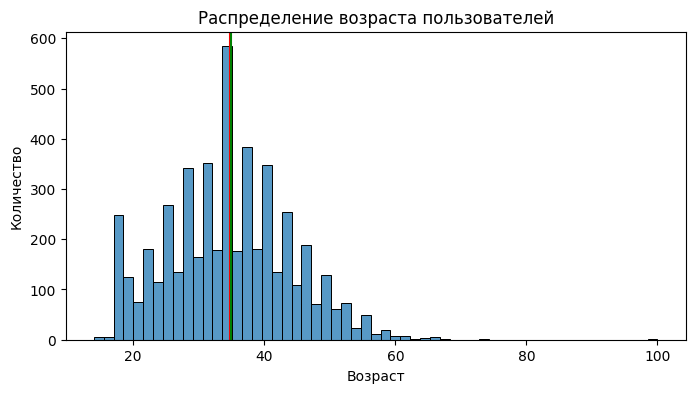

In [546]:
mean_age = users['age'].mean() # считаем среднее
median_age = users['age'].median() # считаем медиану

plt.figure(figsize=(8, 4))
plt.axvline(mean_age, color='red') # добавим на график среднее
plt.axvline(median_age, color='green') # добавим на график медиану
sns.histplot(users['age'])
plt.xlabel("Возраст")
plt.ylabel("Количество")
plt.title("Распределение возраста пользователей")

> Распределение возраста пользователей близко к нормальному с основной концентрацией в диапазоне 25–45 лет. Среднее и медиана практически совпадают, что свидетельствует о симметричности распределения. Наблюдается незначительный правосторонний перекос, обусловленный наличием небольшого числа более возрастных пользователей.

**Доля пользователей по городам**

In [547]:
users['city'] = users['city'].cat.remove_unused_categories() # Удалим категории, которых нет чтобы их не было на графике

In [548]:
city_shares = users["city"].value_counts() / len(users) * 100 # Доля для каждого города
city_shares_sorted = city_shares.sort_values(ascending=True)

Text(0.5, 1.0, 'Доля пользователей по городам')

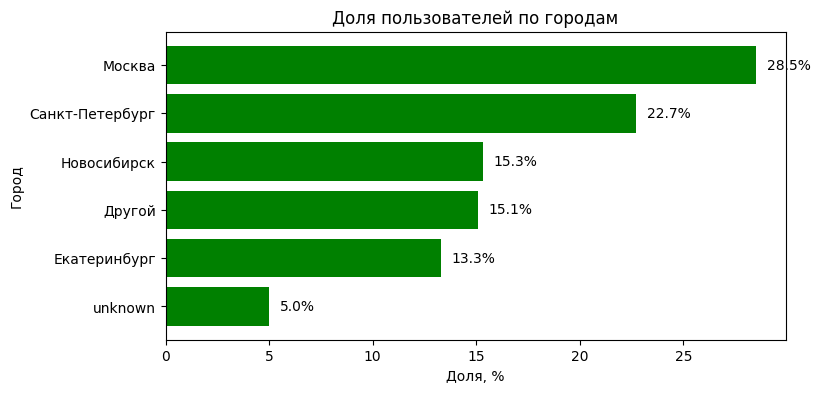

In [549]:
plt.figure(figsize=(8, 4))
plt.barh(city_shares_sorted.index, city_shares_sorted.round(1), color="green")

for i, v in enumerate(city_shares_sorted):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center') # подписи процентов
    
plt.xlabel("Доля, %")
plt.ylabel("Город")
plt.title("Доля пользователей по городам")

> Наибольшая доля пользователей приходится на Москву 28.5% и Санкт-Петербург 22.7%. Далее следуют Новосибирск и категория “Другой” около 15%, а также Екатеринбург около 13%. Доля пользователей с неопределённым городом составляет 5%.

**Распределение пользователей по типам мобильных устройств**

In [550]:
users['device'] = users['device'].cat.remove_unused_categories() # Удалим категории, которых нет чтобы их не было на график

In [551]:
device_counts = users["device"].value_counts() # количество для каждой группы

Text(0.5, 1.0, 'Распределение пользователей по типам мобильных устройств')

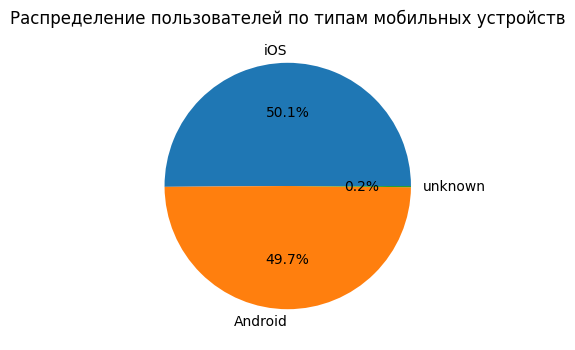

In [552]:
plt.figure(figsize=(4, 4))
plt.pie(device_counts, labels=device_counts.index, autopct="%1.1f%%")
plt.title("Распределение пользователей по типам мобильных устройств")

> Пользователи практически равномерно распределены между устройствами iOS и Android, что говорит об отсутствии смещения выборки по типу устройства.

**Распределение пользователей по группам (A/B)**

Text(0.5, 1.0, 'Распределение пользователей по группам (A/B)')

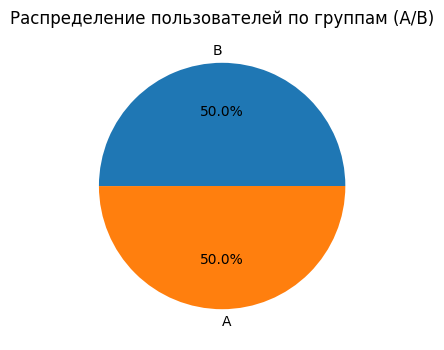

In [553]:
group_counts = users["group"].value_counts() # количество для каждой группы

plt.figure(figsize=(4, 4))
plt.pie(group_counts, labels=group_counts.index, autopct="%1.1f%%")
plt.title("Распределение пользователей по группам (A/B)")

> Пользователи равномерно распределены между контрольной A и тестовой B группами.

#### 4.6 Таблица events (Аналитический и графический анализ)

**Распределение событий в приложении**

Text(0.5, 1.0, 'Распределение событий в приложении')

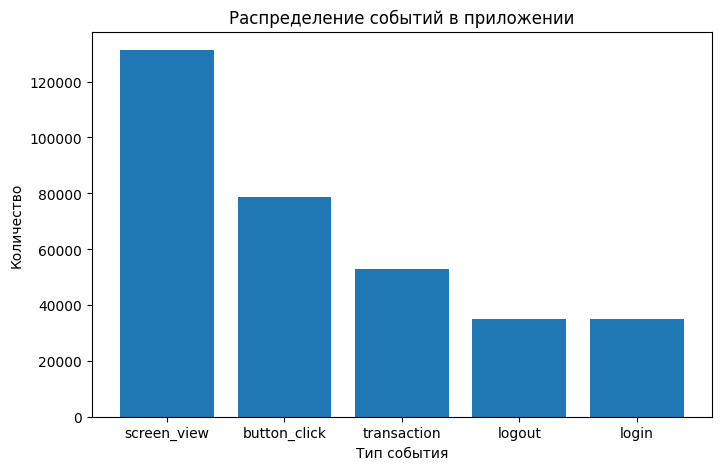

In [554]:
event_counts = events["event_type"].value_counts() # количество для события

plt.figure(figsize=(8, 5))
plt.bar(event_counts.index, event_counts.values)
plt.xlabel("Тип события")
plt.ylabel("Количество")
plt.title("Распределение событий в приложении")

> Распределение событий отражает типичную пользовательскую воронку: большинство пользователей ограничивается просмотром экранов (screen_view), меньшая доля переходит к активным действиям (button_click), и ещё меньшая — совершает транзакции (transaction).

#### 4.6 Таблица c сессиями (Аналитический и графический анализ)

**Распределение длительности сессий**

Text(0.5, 1.0, 'Распределение длительности сессий')

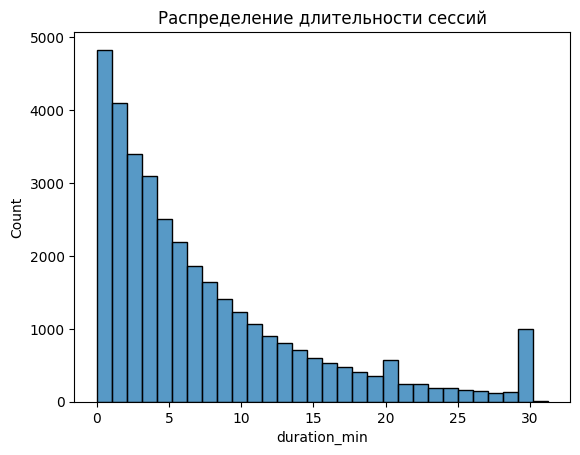

In [555]:
sns.histplot(session_stats['duration_min'], bins=30)
plt.title('Распределение длительности сессий')

> Большинство сессий короткие (до 5–7 минут), при этом наблюдается длинный хвост более длительных сессий (до 30 минут). Это соответствует типичному пользовательскому поведению

## 5. Проведение расчетов и исследований

### 5.1 Расчет ключевых метрик для А/Б-теста

**Рассчет метрик на основе данного дата сета**

In [556]:
session_stats

,user_id,session_id,session_start,session_end,events_count,has_login,has_logout,has_transaction,duration_min
0,user_00000,1,2025-11-02 06:41:06.488811,2025-11-02 06:46:22.269531,6,True,True,False,5.263012
1,user_00000,2,2025-11-05 03:00:06.488811,2025-11-05 03:02:48.724075,12,True,True,True,2.703921
2,user_00000,3,2025-11-07 18:08:06.488811,2025-11-07 18:13:17.380951,9,True,True,True,5.181536
3,user_00000,4,2025-11-09 23:53:06.488811,2025-11-10 00:01:48.552862,12,True,True,False,8.701068
4,user_00001,1,2025-10-28 00:13:06.488811,2025-10-28 00:13:29.439403,11,True,True,True,0.382510
...,...,...,...,...,...,...,...,...,...
35066,user_04999,3,2025-10-30 20:18:06.488811,2025-10-30 20:26:46.858820,6,True,True,True,8.672833
35067,user_04999,4,2025-11-03 02:12:06.488811,2025-11-03 02:37:23.253433,5,True,True,False,25.279410
35068,user_04999,5,2025-11-04 04:57:06.488811,2025-11-04 04:59:51.483693,7,True,True,False,2.749915
35069,user_04999,6,2025-11-04 07:46:06.488811,2025-11-04 07:58:46.647130,5,True,True,True,12.669305


**Количество сессий у каждого пользователя**

In [557]:
sessions_count = (session_stats.groupby('user_id')['session_id'].nunique().reset_index(name='sessions_count'))

In [558]:
sessions_count

,user_id,sessions_count
0,user_00000,4
1,user_00001,5
2,user_00002,6
3,user_00003,12
4,user_00004,8
...,...,...
4995,user_04995,7
4996,user_04996,5
4997,user_04997,4
4998,user_04998,8


**Cреднее число событий за сессии у каждого пользователя**

In [559]:
events_per_session = (session_stats.groupby('user_id')['events_count'].mean().reset_index(name='events_per_session'))

In [560]:
events_per_session

,user_id,events_per_session
0,user_00000,9.750000
1,user_00001,10.400000
2,user_00002,10.000000
3,user_00003,9.166667
4,user_00004,11.375000
...,...,...
4995,user_04995,6.857143
4996,user_04996,9.600000
4997,user_04997,9.000000
4998,user_04998,9.250000


**Конверсия в транзакцию (доля сессий для каждого пользователя, в которых была хотя бы одна transaction)**

In [561]:
conversion_rate = (session_stats.groupby('user_id')['has_transaction'].mean().reset_index(name='conversion_rate'))

In [562]:
conversion_rate

,user_id,conversion_rate
0,user_00000,0.500000
1,user_00001,1.000000
2,user_00002,1.000000
3,user_00003,0.750000
4,user_00004,0.750000
...,...,...
4995,user_04995,0.571429
4996,user_04996,0.800000
4997,user_04997,0.750000
4998,user_04998,0.875000


**Объединяем всё**

In [563]:
user_metrics = (
    sessions_count
    .merge(events_per_session, on='user_id')
    .merge(conversion_rate, on='user_id')
    .merge(users[['user_id', 'group']], on='user_id'))

In [564]:
user_metrics

,user_id,sessions_count,events_per_session,conversion_rate,group
0,user_00000,4,9.750000,0.500000,A
1,user_00001,5,10.400000,1.000000,B
2,user_00002,6,10.000000,1.000000,A
3,user_00003,12,9.166667,0.750000,B
4,user_00004,8,11.375000,0.750000,A
...,...,...,...,...,...
4995,user_04995,7,6.857143,0.571429,B
4996,user_04996,5,9.600000,0.800000,A
4997,user_04997,4,9.000000,0.750000,B
4998,user_04998,8,9.250000,0.875000,A


**Агрегировать метрики по группам А и B**

In [565]:
ab_metrics = (user_metrics.groupby('group')
    .agg({
        'sessions_count': 'mean',
        'events_per_session': 'mean',
        'conversion_rate': 'mean'})
    .reset_index())

> Конверсия рассчитывалась на уровне пользователя как доля сессий с транзакцией, после чего агрегировалась по группам. Такой подход позволяет избежать смещения, связанного с разным числом сессий у пользователей.

In [566]:
ab_metrics

,group,sessions_count,events_per_session,conversion_rate
0,A,6.0452,9.479595,0.770308
1,B,7.9832,9.523982,0.779426


> В группе B более высокое среднее количество сессий на пользователя, что может свидетельствовать о росте вовлечённости пользователей. При этом среднее количество событий на сессию и конверсия в транзакцию на одном уровне в обеих группах.

**Графики для метрик**

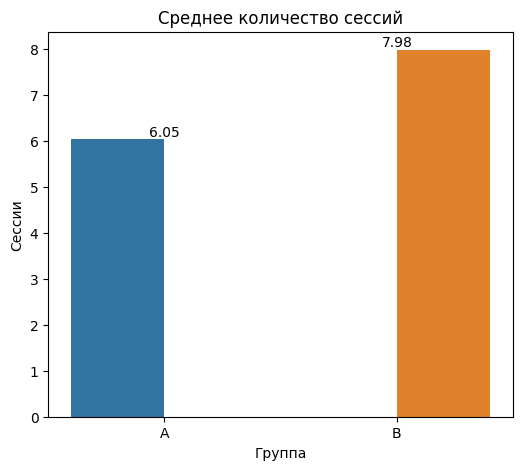

In [567]:
plot_metric(ab_metrics, 'sessions_count', 'Среднее количество сессий', 'Сессии')

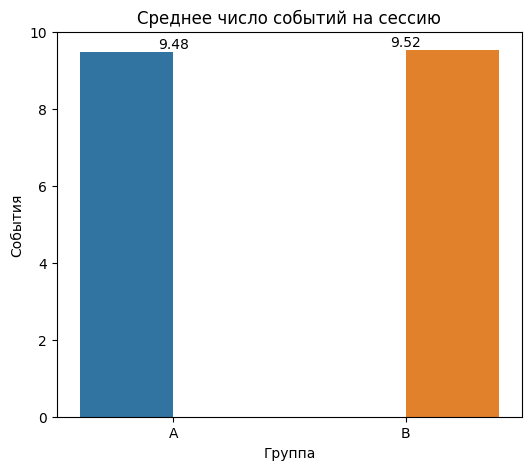

In [568]:
plot_metric(ab_metrics, 'events_per_session', 'Среднее число событий на сессию', 'События')

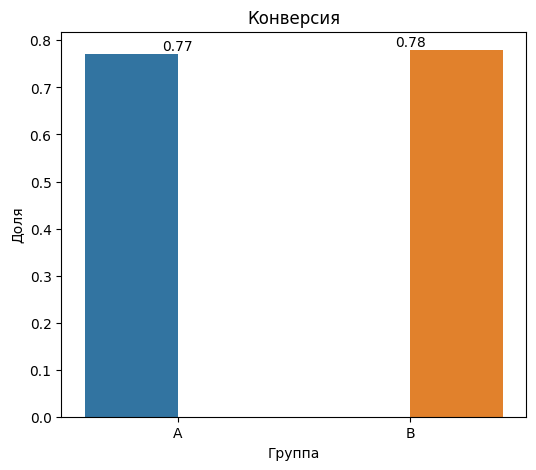

In [569]:
plot_metric(ab_metrics, 'conversion_rate', 'Конверсия', 'Доля')

### 5.2 Построение сводных таблиц

#### Среднее количество транзакций на пользователя по группам и типам устройств

In [570]:
# считаем количество транзакций на пользователя
transactions_per_user = (events[events['event_type'] == 'transaction'].groupby('user_id').size().reset_index(name='transactions_count'))

# добавляем group и device
transactions_per_user = transactions_per_user.merge(users[['user_id', 'group', 'device']], on='user_id', how='left')

# сводная таблица
pivot_1 = pd.pivot_table(transactions_per_user, values='transactions_count', index='group', columns='device', aggfunc='mean')

pivot_1

device,Android,iOS,unknown
group,,,
A,9.283172,8.954254,10.400000
B,12.213247,12.054270,9.333333


#### Количество уникальных пользователей, совершивших хотя бы одну транзакцию, по городам и группам.

In [571]:
users_with_transaction = events[events['event_type'] == 'transaction']['user_id'].unique() # получаем на выходе список

users_tx = users[users['user_id'].isin(users_with_transaction)] # делаем табличку из айди, которые есть в списке

# сводная таблица
pivot_2 = pd.pivot_table(users_tx, values='user_id', index='city', columns='group', aggfunc='nunique')

pivot_2

group,A,B
city,,
Другой,381,369
Екатеринбург,335,327
Москва,718,703
Новосибирск,366,396
Санкт-Петербург,557,580
unknown,130,119


#### Распределение событий screen_view по типам экранов (если бы такие данные были) или просто общее количество.

In [572]:
screen_views = events[events['event_type'] == 'screen_view']
pivot_3 = screen_views['screen_name'].value_counts()
pivot_3

screen_name
transfers    21534
settings     21505
profile      21502
cards        21487
payments     21349
main         21344
Name: count, dtype: int64

In [573]:
events['event_type'].value_counts()

event_type
screen_view     131364
button_click     78633
transaction      52935
logout           35077
login            35071
Name: count, dtype: int64

### 5.3 Адекватность данных

Text(0.5, 1.0, 'Распределение длительности сессий')

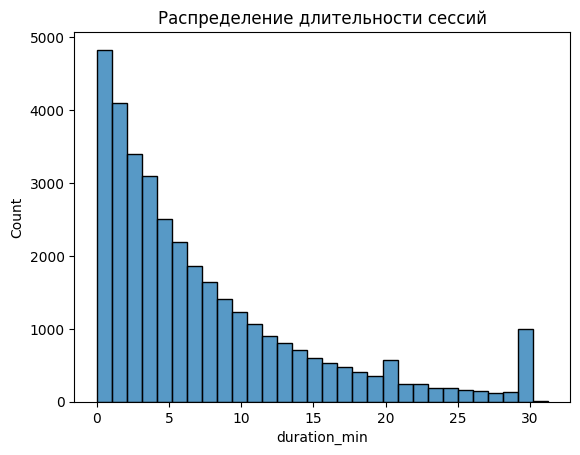

In [574]:
sns.histplot(session_stats['duration_min'], bins=30)
plt.title('Распределение длительности сессий')

In [575]:
session_stats['duration_min'].describe()

count    35071.000000
mean         7.469888
std          7.285485
min          0.000000
25%          2.042369
50%          5.057127
75%         10.467079
max         31.250000
Name: duration_min, dtype: float64

> Средняя длительность сессии в мобильных приложениях обычно составляет от 3 до 7 минут в зависимости от типа приложения. В анализируемых данных средняя длительность сессии составляет около 7.5 минут, что находится в пределах ожидаемых значений. 

## 6. Проверка гипотез

### H1: Конверсия в транзакцию в группе B выше, чем в группе A

> Бинарный характер данных (наличие или отсутствие транзакции)
> 
> Независимость наблюдений (сессия одного пользователя не влияет на сессию другого)
>
> Достаточный объём выборки (много наблюдений)
>
> Независимость сравниваемых групп (группы были сформированы рондомно, по условию)

In [576]:
# Добавляем group к session_stats по user_id
conv_by_group = session_stats.merge(users[['user_id', 'group']], on='user_id')

# Считаем число сессий с транзакцией с делением по группам
success = conv_by_group.groupby('group')['has_transaction'].sum()

# общее число сессий с делением по группам
total = conv_by_group.groupby('group')['has_transaction'].count()

success, total, success/total

(group
 A    11640
 B    15516
 Name: has_transaction, dtype: int64,
 group
 A    15113
 B    19958
 Name: has_transaction, dtype: int64,
 group
 A    0.770198
 B    0.777433
 Name: has_transaction, dtype: float64)

> Для проведения статистического теста необходимо использовать агрегированные данные на уровне наблюдений (сессий), так как z-тест работает с количеством успешных событий и общим числом наблюдений.

> H0: p_B <= p_A (Нет статистически значимой разницы между конверсиями в группе B и в группе A)
> 
> H1: p_B > p_A (Конверсия в группе B выше)

In [577]:
z_stat, p_value = proportions_ztest( count=[success['B'], success['A']], nobs=[total['B'], total['A']], alternative='larger')

print("z-stat:", z_stat, "p-value:", p_value)

z-stat: 1.6049962720011497 p-value: 0.05424731254984935


> При уровне значимости 0.05 различия не являются статистически значимыми (p-value = 0.054 > 0.05). P-value близко к пороговому, что может свидетельствовать о слабой тенденции к увеличению конверсии в группе B. При уровне значимости 0.10 различия можно считать статистически значимыми

**Критерий Пирсона CHI квадрат**

In [578]:
# считаем успехи и неуспехи
success_A = success['A']
success_B = success['B']

fail_A = total['A'] - success_A
fail_B = total['B'] - success_B

# таблица
table = pd.DataFrame({'transaction': [success_A, success_B], 
                      'no_transaction': [fail_A, fail_B]}, index=['A', 'B'])

table

,transaction,no_transaction
A,11640,3473
B,15516,4442


> H0: p_A = p_B
>
> H1: p_A != p_B

In [579]:
chi2, p_value, dof, expected = chi2_contingency(table)
p_value

np.float64(0.11136247617311863)

> По результатам CHI квадрат теста (p-value = 0.11) статистически значимых различий между группами A и B не выявлено. Данный результат согласуется с выводами Z-теста, который показал лишь слабую тенденцию к увеличению конверсии в группе B. Отсутствуют статистически значимые доказательства того, что конверсия в транзакцию в группе B выше, чем в группе A.

### H2: Среднее количество сессий на пользователя в группе B отличается от группы A

**Проверка на нормальность данных**

In [580]:
group_A = user_metrics[user_metrics['group'] == 'A']['sessions_count']
group_B = user_metrics[user_metrics['group'] == 'B']['sessions_count']

In [581]:
print("A:", shapiro(group_A)) # не норм
print("B:", shapiro(group_B)) # не норм

A: ShapiroResult(statistic=np.float64(0.970102120397906), pvalue=np.float64(2.0249371156933392e-22))
B: ShapiroResult(statistic=np.float64(0.9809367058516509), pvalue=np.float64(8.266784951258413e-18))


Text(0, 0.5, 'Частота')

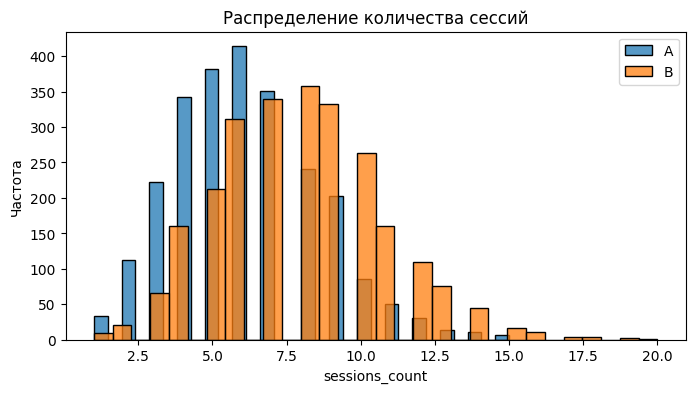

In [582]:
plt.figure(figsize=(8, 4))

sns.histplot(group_A, bins=30, label='A')
sns.histplot(group_B, bins=30, label='B')
plt.legend()
plt.title("Распределение количества сессий")
plt.xlabel("sessions_count")
plt.ylabel("Частота")

Text(0.5, 1.0, 'Boxplot количества сессий по группам')

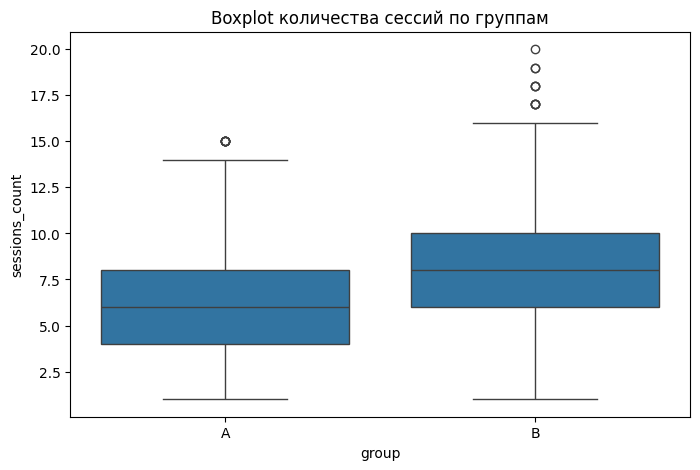

In [583]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=user_metrics, x='group', y='sessions_count')
plt.title("Boxplot количества сессий по группам")

> Наличие асимметрии и выбросов, ненормальность распределения, мы будем использовать U-test.

>H0: μ_B <= μ_A (Среднее количество сессий на пользователя в группе B меньше или равно группе A)
>
>H1: μ_B > μ_A (Среднее количество сессий на пользователя в группе B больше, чем в группе A)

In [584]:
stat, p_value = mannwhitneyu(group_B, group_A, alternative='greater')

print("stat:", stat, "p-value:", p_value)

stat: 4376396.5 p-value: 1.1692280780246377e-134


> Среднее количество сессий на пользователя в группе B статистически больше, чем в группе A. p-value ±=0

### H3: Среднее количество событий на сессию в группе B больше, чем в группе A

In [585]:
group_A = user_metrics[user_metrics['group'] == 'A']['events_per_session']
group_B = user_metrics[user_metrics['group'] == 'B']['events_per_session']

Text(0.5, 1.0, 'Boxplot количества сессий по группам')

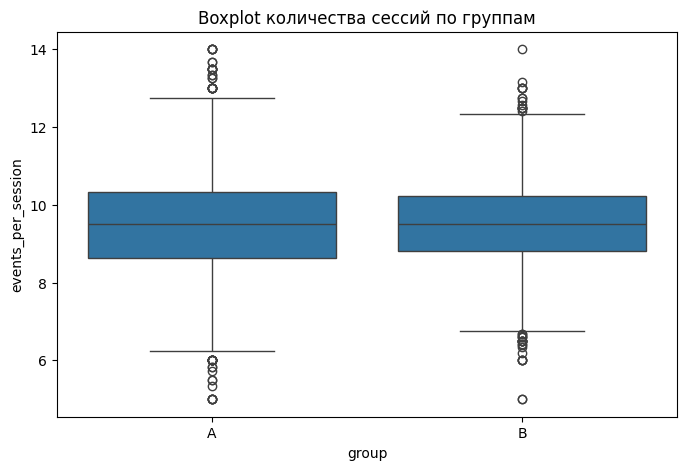

In [586]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=user_metrics, x='group', y='events_per_session')
plt.title("Boxplot количества сессий по группам")

>H0: μ_B ≤ μ_A (среднее количество событий на сессию в группе B не превышает группу A)
>
>H1: μ_B > μ_A (Среднее количество событий на сессию в группе B больше чем в группе A)

In [587]:
print("A:", shapiro(group_A)) # не норм
print("B:", shapiro(group_B)) # не норм

A: ShapiroResult(statistic=np.float64(0.9965897687641052), pvalue=np.float64(2.0404975547018868e-05))
B: ShapiroResult(statistic=np.float64(0.9977539869142561), pvalue=np.float64(0.0012148735398195758))


> Наличие асимметрии и выбросов, ненормальность распределения, мы будем использовать U-test.

In [588]:
stat, p_value = mannwhitneyu(group_B, group_A, alternative='greater')

print("stat:", stat, "p-value:", p_value)

stat: 3203312.5 p-value: 0.06242674161359382


> Cтатистически значимых различий в среднем количестве событий на сессию между группами A и B не выявлено, однако при уровне значимости 0.10 различия можно считать слабо значимыми, что может указывать на тенденцию к увеличению количества событий в группе B.

### H4: Время, проведенное в приложении (длина сессии), в группе B больше, чем в группе A

In [589]:
conv_by_group = session_stats.merge(users[['user_id', 'group']], on='user_id')

In [590]:
group_A = conv_by_group[conv_by_group['group'] == 'A']['duration_min']
group_B = conv_by_group[conv_by_group['group'] == 'B']['duration_min']

In [591]:
print("A:", shapiro(group_A)) # не норм
print("B:", shapiro(group_B)) # не норм

A: ShapiroResult(statistic=np.float64(0.8518395307472535), pvalue=np.float64(2.6493525414776596e-79))
B: ShapiroResult(statistic=np.float64(0.8758332469171176), pvalue=np.float64(1.466651805022741e-81))


/Users/prokofiev/miniconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15113.
  res = hypotest_fun_out(*samples, **kwds)
/Users/prokofiev/miniconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 19958.
  res = hypotest_fun_out(*samples, **kwds)


Text(0.5, 1.0, 'Boxplot количества сессий по группам')

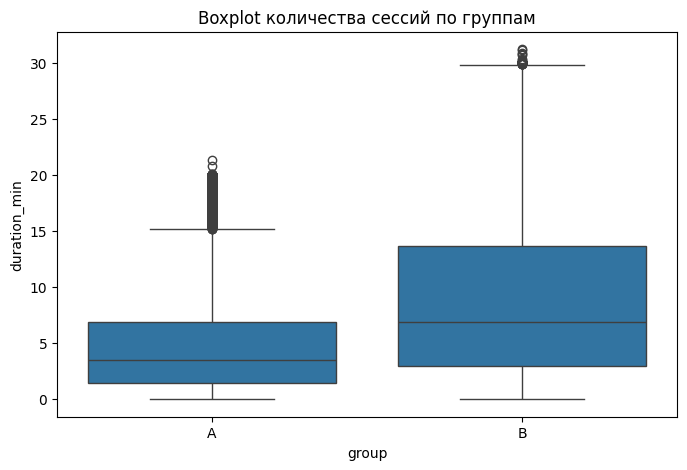

In [592]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=conv_by_group, x='group', y='duration_min')
plt.title("Boxplot количества сессий по группам")

> Из-за наличие выбросов и асимметрии был выбран непараметрический подход (U-test).

> H0: μ_B ≤ μ_A (среднее время, проведённое в приложении, в группе B не превышает группу A)
> 
> H1: μ_B > μ_A (среднее время, проведённое в приложении, в группе B больше, чем в группе A)

In [593]:
stat, p_value = mannwhitneyu(group_B, group_A, alternative='greater')

print("stat:", stat, "p-value:", p_value)

stat: 201556035.5 p-value: 0.0


In [594]:
print("A mean:", group_A.mean())
print("B mean:", group_B.mean())
print("A median:", group_A.median())
print("B median:", group_B.median())

A mean: 4.885820482717969
B mean: 9.426648205788823
A median: 3.473377483333333
B median: 6.907717933333333


> Среднее время, проведённое в приложении, значительно выше в группе B (9.43) по сравнению с группой A (4.89), что также подтверждается медианными значениями. Критерий Манна–Уитни показал p-value ±= 0, что свидетельствует о статистически значимом различии между группами.

### Результат проверки гипотез

> **Новый интерфейс увеличивает вовлечённость пользователей (сессии и время), однако не даёт статистически значимого роста конверсии.**

## 7. Регрессионное моделирование

### 7.1 Подготовка данных

**Предобработка данных временного ряда**

In [595]:
# День недели
visits["day_of_week"] = visits["date"].dt.dayofweek
# Месяц
visits["month"] = visits["date"].dt.month

**Cмотрим на наш временной ряд**

Text(0, 0.5, 'Количество посещений')

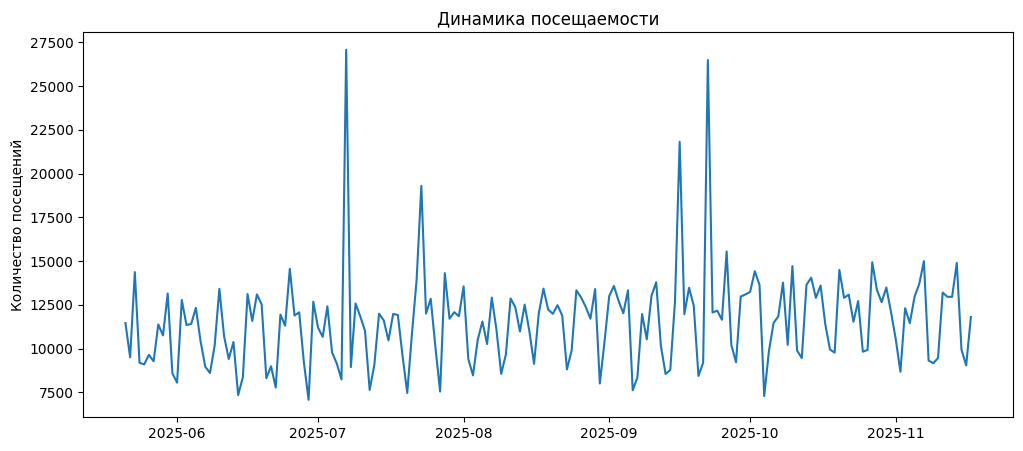

In [596]:
plt.figure(figsize=(12,5))
plt.plot(visits["date"], visits["visits"])
plt.title("Динамика посещаемости")
plt.ylabel("Количество посещений")

> Тренда нет, ряд с наличием сезонности (похоже на недельную сезонность). Также есть выбросы - всплекси посещаемости.

In [597]:
# Создание лаговых признаков
visits["lag_1"] = visits["visits"].shift(1) # вчера
visits["lag_3"] = visits["visits"].shift(3) # паттерн
visits["lag_7"] = visits["visits"].shift(7) # недельная сезонность

visits

,date,visits,holiday_flag,day_of_week,month,lag_1,lag_3,lag_7
0,2025-05-21,11461,1,2,5,NaN,NaN,NaN
1,2025-05-22,9503,0,3,5,11461.0,NaN,NaN
2,2025-05-23,14367,0,4,5,9503.0,NaN,NaN
3,2025-05-24,9185,1,5,5,14367.0,11461.0,NaN
4,2025-05-25,9098,1,6,5,9185.0,9503.0,NaN
...,...,...,...,...,...,...,...,...
176,2025-11-13,12956,0,3,11,12960.0,9459.0,13688.0
177,2025-11-14,14896,0,4,11,12956.0,13202.0,14997.0
178,2025-11-15,9938,1,5,11,14896.0,12960.0,9314.0
179,2025-11-16,9039,1,6,11,9938.0,12956.0,9165.0


>Лаговые признаки отражают поведение пользователей: посещаемость приложения сегодня часто зависит от активности в предыдущие дни (например, если человек зашёл вчера, он с большей вероятностью зайдёт и сегодня). \
День недели и праздники влияют на распорядок дня — в выходные и праздничные дни активность может меняться (например, люди чаще проверяют баланс или переводят деньги близким), а в будни пики могут приходиться на перерывы или после работы.

**ACF и PACF**

Text(0.5, 1.0, 'ACF')

<Figure size 1200x700 with 0 Axes>

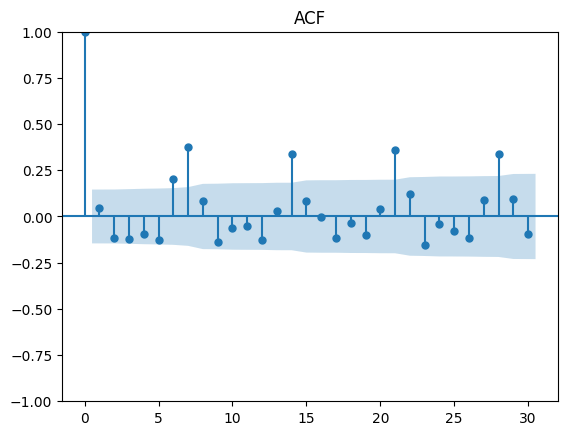

In [598]:
# Автокорреляция
plt.figure(figsize=(12,7))
plot_acf(visits["visits"], lags=30)
plt.title("ACF")

> ACF показывает наличие значимой автокорреляции на лаге 7 и кратных ему значениях, есть недельная сезонность во временном ряду.

Text(0.5, 1.0, 'PACF')

<Figure size 1200x500 with 0 Axes>

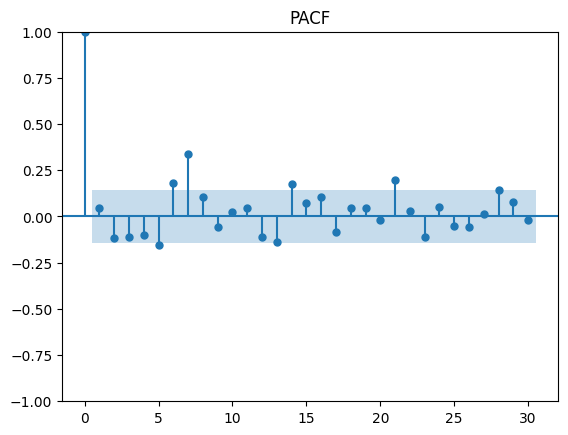

In [599]:
# "Чистая" автокорреляция
plt.figure(figsize=(12,5))
plot_pacf(visits["visits"], lags=30)
plt.title("PACF")

> PACF подтверждает влияние первых лагов, особенно lag_1 и lag_7, есть краткосрочная зависимость и сезонность.

 ### 7.2 Разделение данных

In [600]:
visits = visits.dropna() # удаляем пропуски

In [601]:
# Разделение на train и test по времени
split_index = int(len(visits) * 0.8)
train = visits.iloc[:split_index]
test = visits.iloc[split_index:]

# Признаки и целевая переменная
columns = ['day_of_week', 'month', 'holiday_flag', 'lag_1', 'lag_3', 'lag_7']

x_train = train[columns]
x_test = test[columns]

y_train = train["visits"]
y_test = test["visits"]

> После создания лаговых признаков были удалены строки с пропусками. В качестве признаков использовались календарные и лаговые переменные, отражающие сезонность и зависимость от прошлых значений. Данные были разделены на обучающую и тестовую выборки в соотношении 80/20 без перемешивания, чтобы сохранить временную структуру ряда.

 ### 7.2 Обучение моделей и прогноз

#### Linear Regression

In [602]:
model = LinearRegression()

linear_pred = regression_stat(model, name="Linear Regression")


=== Linear Regression ===
MAE: 1040.94 посещений
MAPE: 8.98%
RMSE: 1578.81
Модель ошибается в среднем на 1040.94 посещений, что составляет 8.98% от среднего значения


**График предсказаний для модели Линейной Регрессии**

Text(0, 0.5, 'Количество посещений')

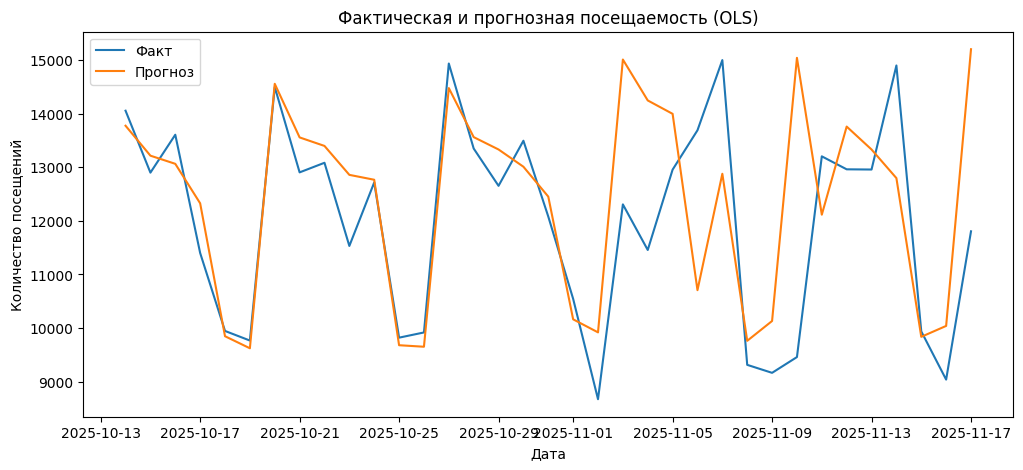

In [603]:
plt.figure(figsize=(12,5))
plt.plot(test["date"], y_test, label="Факт")
plt.plot(test["date"], linear_pred, label="Прогноз")
plt.legend()
plt.title("Фактическая и прогнозная посещаемость (OLS)")
plt.xlabel("Дата")
plt.ylabel("Количество посещений")

#### Эконометрический анализ (OLS)

> Помимо построения прогнозной модели, был применён эконометрический подход (OLS). Это позволило не только оценить качество прогноза, но и проанализировать влияние отдельных факторов на посещаемость, а также проверить их статистическую значимость.
>
> Таким образом, использование OLS дополняет модель машинного обучения и позволяет получить интерпретируемые результаты.

In [604]:
x_train_sm = sm.add_constant(x_train) # константы

model_sm = sm.OLS(y_train, x_train_sm).fit()
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 visits   R-squared:                       0.414
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     15.51
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.05e-13
Time:                        23:03:27   Log-Likelihood:                -1267.5
No. Observations:                 139   AIC:                             2549.
Df Residuals:                     132   BIC:                             2570.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.269e+04   1653.117      7.674      0.000    9416.556     1.6e+04
day_of_week   -416.0057    157.088     -2.648      0.009    -726.742    -105.270
month          392.0812    150.313      2.608      0.010      94.747     689.416
holiday_flag -2594.3160    680.975     -3.810      0.000   -3941.351   -1247.281
lag_1           -0.1234      0.071     -1.747      0.083      -0.263       0.016
lag_3           -0.0139      0.072     -0.194      0.846      -0.155       0.128
lag_7           -0.0505      0.085     -0.595      0.553      -0.218       0.117
==============================================================================
Omnibus:                      129.119   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1758.070
Skew:                           3.318   Prob(JB):                         0.00
Kurtosis:                      19.109   Cond. No.                     1.73e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.73e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

>По результатам оценки OLS-модели установлено, что модель в целом является статистически значима, хотя бы один коэффициент не равен нулю  (F-statistic:	15.51). Коэффициент детерминации R² = 0.41.
>
>Значимыми факторами являются день недели (p = 0.009) и месяц (p = 0.010), что подтверждает наличие календарной сезонности. Лаговый признак lag_1 является слабо значимым на уровне 10% (p = 0.083), что указывает на наличие краткосрочной зависимости. Остальные признаки не оказывают статистически значимого влияния на посещаемость. holiday_flag влияет глубоко отрицательно (p < 0.01).
>
>Значение статистики Дарбина–Уотсона 1.98 близко к 2, что свидетельствует об отсутствии автокорреляции остатков.
>
>Диагностика модели выявила признаки мультиколлинеарности (Cond. No = 1.73e+05), а также существенное отклонение остатков от нормального распределения (Prob(JB) = 0, высокая асимметрия и эксцесс), что типично для поведенческих временных рядов.

#### Полиномиальная регрессия

In [605]:
degree = 2
poly_reg_pipeline = make_pipeline(
    PolynomialFeatures(degree, interaction_only=True),
    LinearRegression())

poly_pred = regression_stat(poly_reg_pipeline, name="Polynomial Regression")


=== Polynomial Regression ===
MAE: 1101.03 посещений
MAPE: 9.48%
RMSE: 1647.81
Модель ошибается в среднем на 1101.03 посещений, что составляет 9.48% от среднего значения


**График предсказаний для модели полиномиальной регрессии**

Text(0, 0.5, 'Количество посещений')

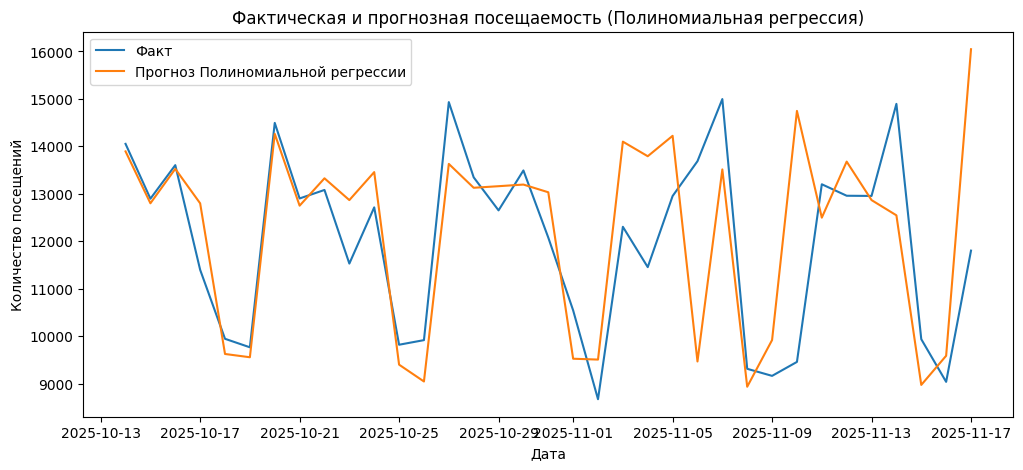

In [606]:
plt.figure(figsize=(12,5))
plt.plot(test["date"], y_test, label="Факт")
plt.plot(test["date"], poly_pred, label="Прогноз Полиномиальной регрессии")
plt.legend()
plt.title("Фактическая и прогнозная посещаемость (Полиномиальная регрессия)")
plt.xlabel("Дата")
plt.ylabel("Количество посещений")

#### Случайный лес

In [607]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf_pred = regression_stat(rf, name="Random Forest Regressor")


=== Random Forest Regressor ===
MAE: 1264.47 посещений
MAPE: 10.84%
RMSE: 2024.09
Модель ошибается в среднем на 1264.47 посещений, что составляет 10.84% от среднего значения


**График предсказаний для модели Регрессии 'Случайный лес'**

Text(0, 0.5, 'Количество посещений')

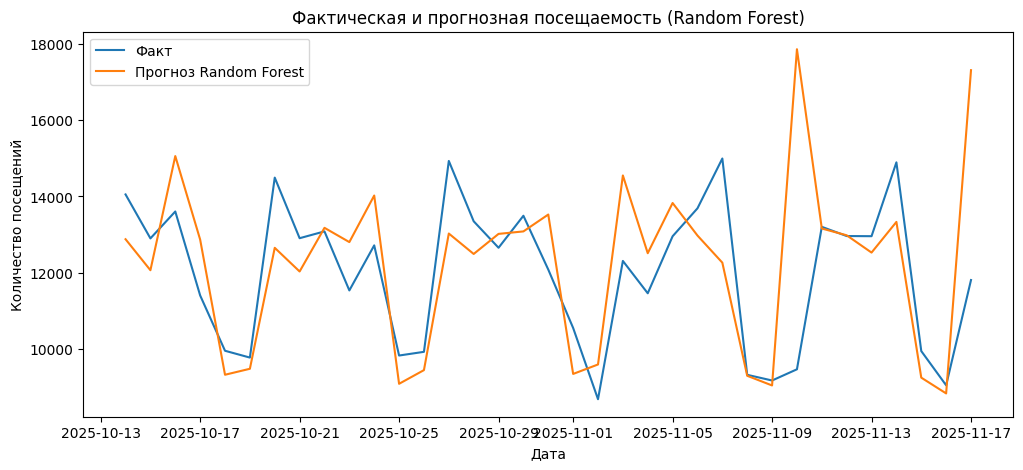

In [608]:
plt.figure(figsize=(12,5))
plt.plot(test["date"], y_test, label="Факт")
plt.plot(test["date"], rf_pred, label="Прогноз Random Forest")
plt.legend()
plt.title("Фактическая и прогнозная посещаемость (Random Forest)")
plt.xlabel("Дата")
plt.ylabel("Количество посещений")

> **Видим, что модель с линейной регрессией имеет лучшую точность (MAPE = 8.6%), чем модель с регрессией "Случайный лес".**
> 
> **Анализ OLS подтвердил значимость календарных факторов, тогда как лаговые переменные демонстрируют лишь небольшую значимость.**

## 8 Формирование дата сета для дашборда

**Подготовить итоговые таблицы для дашборда**

In [609]:
users_dash = user_metrics.merge(
    users[['user_id', 'city', 'device', 'age']],
    on='user_id',
    how='left')

users_dash

,user_id,sessions_count,events_per_session,conversion_rate,group,city,device,age
0,user_00000,4,9.750000,0.500000,A,Другой,Android,39
1,user_00001,5,10.400000,1.000000,B,Москва,iOS,33
2,user_00002,6,10.000000,1.000000,A,Новосибирск,iOS,41
3,user_00003,12,9.166667,0.750000,B,Санкт-Петербург,Android,50
4,user_00004,8,11.375000,0.750000,A,unknown,Android,32
...,...,...,...,...,...,...,...,...
4995,user_04995,7,6.857143,0.571429,B,Москва,iOS,34
4996,user_04996,5,9.600000,0.800000,A,Санкт-Петербург,Android,42
4997,user_04997,4,9.000000,0.750000,B,Санкт-Петербург,Android,66
4998,user_04998,8,9.250000,0.875000,A,Новосибирск,iOS,43


**Таблица для временного ряда с прогнозом**

In [612]:
forecast_dash = test[['date']].copy()
forecast_dash['actual_visits'] = y_test.values
forecast_dash['predicted_visits'] = linear_pred
forecast_dash.head()

,date,actual_visits,predicted_visits
146,2025-10-14,14053,13772.584220
147,2025-10-15,12898,13214.491681
148,2025-10-16,13605,13062.490803
149,2025-10-17,11400,12326.261049
150,2025-10-18,9946,9847.598341


In [611]:
# скачиваем
users_dash.to_csv("users_dash.csv", index=False)
forecast_dash.to_csv("forecast_dash.csv", index=False)